# Taller — Regresión logística
## Caso: abandono de producto financiero

**Curso:** Machine Learning en Economía y Finanzas · FCEA · Clase 9 · 2026-2

Este cuaderno está orientado al archivo `abandono_producto_financiero.csv` que se encuentra en la misma carpeta del proyecto. La variable respuesta es binaria: `abandono = 1` si el cliente cerró la relación y `abandono = 0` si permanece.

La idea es estimar:

$$
P(\text{abandono} = 1 \mid x) = \Lambda(x\beta)
$$

con `statsmodels` usando `smf.logit` y comparando con un ajuste OLS como referencia.


# Punto 1. Estructura de los datos

En esta parte revisamos la base como un conjunto de observaciones; confirmamos la unidad de análisis, la variable dependiente, el número de filas y columnas, los tipos de variables y los vacíos. Esto permite validar que el dataset es compatible con el modelo logit antes de estimar.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = False

# Cargar la base que está en la misma carpeta del proyecto
NOTEBOOK_DIR = Path.cwd()
DATA_CANDIDATES = [
    NOTEBOOK_DIR / "abandono_producto_financiero.csv",
    NOTEBOOK_DIR / "abandono_producto_financiero.xlsx",
    NOTEBOOK_DIR / "abandono_producto_financiero.xls",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"No se encontró la base de datos en {NOTEBOOK_DIR}. "
        "Verifica que el archivo CSV o Excel esté en la misma carpeta que este notebook."
    )

if DATA_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH)

# Se asume que la respuesta binaria se llama abandono
if "abandono" in df.columns:
    df["abandono"] = df["abandono"].astype(int)

# Vista inicial de los datos
print(f"Archivo cargado: {DATA_PATH.name}")
print(f"Forma del DataFrame: {df.shape}")
df.head()


Archivo cargado: abandono_producto_financiero.csv
Forma del DataFrame: (10000, 14)


,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Punto 1: inspección de la estructura
print("Columnas:")
print(df.columns.tolist())
print("\nTipos de variables:")
print(df.dtypes)
print("\nNúmero de nulos por columna:")
print(df.isna().sum())
print("\nResumen de la variable respuesta:")
print(df["abandono"].value_counts(dropna=False))
print("\nProporción de la variable respuesta:")
print(df["abandono"].value_counts(normalize=True, dropna=False))


Columnas:
['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']

Tipos de variables:
numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64
dtype: object

Número de nulos por columna:
numero_fila           0
id_cliente            0
apellido              0
puntaje_crediticio    0
pais                  0
sexo                  0
edad                  0
antiguedad            0
saldo                 0
numero_productos      0
tiene_tarjeta         0
miembro_activo        0
salario_estimado   

## Observación del punto 1

La base tiene una unidad de observación por cliente y una variable respuesta binaria (`abandono`). La estructura confirma que el problema encaja con una regresión logística: se trabaja con un corte transversal, con atributos del cliente y del vínculo con el banco, y con un desenlace ya observado.


En Colab: runtime de **Python**. Si el CSV no está, la celda de carga abre el diálogo para subirlo.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = False

# Cargar la base que está en la misma carpeta del proyecto
NOTEBOOK_DIR = Path.cwd()
DATA_CANDIDATES = [
    NOTEBOOK_DIR / "abandono_producto_financiero.csv",
    NOTEBOOK_DIR / "abandono_producto_financiero.xlsx",
    NOTEBOOK_DIR / "abandono_producto_financiero.xls",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"No se encontró la base de datos en {NOTEBOOK_DIR}. "
        "Verifica que el archivo CSV o Excel esté en la misma carpeta que este notebook."
    )

if DATA_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH)

# Se asume que la respuesta binaria se llama abandono
if "abandono" in df.columns:
    df["abandono"] = df["abandono"].astype(int)

# Vista inicial de los datos
print(f"Archivo cargado: {DATA_PATH.name}")
print(f"Forma del DataFrame: {df.shape}")
df.head()


In [ ]:
# Carga desde la ruta local del proyecto; no depende de Colab
credit = pd.read_csv(CSV, index_col=0)
credit.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
credit.tail()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,27,male,2,own,moderate,moderate,4576,45,car,good


In [4]:
credit.columns.tolist()


['Age',
 'Sex',
 'Job',
 'Housing',
 'Saving accounts',
 'Checking account',
 'Credit amount',
 'Duration',
 'Purpose',
 'Risk']

In [5]:
credit.shape


(1000, 10)

In [6]:
credit.dtypes


Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object

In [7]:
credit.describe(include='all')


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


La primera columna del CSV es un índice (`index_col=0`). Los nombres con espacio se renombran para la fórmula. `Risk` queda como categoría con orden `bad`, `good`, y `good` = 1 si `Risk` es `good`. En `C(...)`, la referencia es el **primer** nivel del factor.


In [8]:
credit = credit.rename(columns={
    "Saving accounts": "Saving_accounts",
    "Checking account": "Checking_account",
    "Credit amount": "Credit_amount",
})

credit["Risk"] = pd.Categorical(credit["Risk"], categories=["bad", "good"])
credit["Sex"] = credit["Sex"].astype("category")
credit["Housing"] = credit["Housing"].astype("category")
credit["Purpose"] = credit["Purpose"].astype("category")
credit["Job"] = credit["Job"].astype("category")
credit["good"] = (credit["Risk"] == "good").astype(int)

credit.columns.tolist()


['Age',
 'Sex',
 'Job',
 'Housing',
 'Saving_accounts',
 'Checking_account',
 'Credit_amount',
 'Duration',
 'Purpose',
 'Risk',
 'good']

In [9]:
# Referencia de Risk: bad (0). El 1 es good.
credit[["Risk", "good"]].head()


,Risk,good
0,good,1
1,bad,0
2,good,1
3,good,1
4,bad,0


In [10]:
credit.head(15)

,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose,Risk,good
0,67,male,2,own,NaN,little,1169,6,radio/TV,good,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,0
2,49,male,1,own,little,NaN,2096,12,education,good,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,1
4,53,male,2,free,little,little,4870,24,car,bad,0
5,35,male,1,free,NaN,NaN,9055,36,education,good,1
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good,1
7,35,male,3,rent,little,moderate,6948,36,car,good,1
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good,1
9,28,male,3,own,little,moderate,5234,30,car,bad,0


## Diccionario

Cada fila es una solicitud. Un `NA` en las cuentas es el valor “no informado” de la fuente.


### Respuesta

| Nombre | Español | Niveles |
|---|---|---|
| `Risk` | Calidad de pago | `good`: cumplió. `bad`: incumplió. |


### Numéricas

| Nombre | Español | Unidades |
|---|---|---|
| `Age` | Edad | años |
| `Credit_amount` | Monto pedido | unidades monetarias |
| `Duration` | Plazo del crédito | meses |


### Sexo y empleo (`Job`)

| Nivel | Significado |
|---|---|
| `male` / `female` | Sexo del solicitante. En el logit, la referencia es el primer nivel (`female`, orden alfabético). |
| `Job = 0` | No calificado y no residente. |
| `Job = 1` | No calificado y residente. |
| `Job = 2` | Calificado / empleado. |
| `Job = 3` | Alta cualificación, dirección o independiente. |


### Vivienda (`Housing`)

| Nivel | Español |
|---|---|
| `own` | Vivienda propia |
| `rent` | Arriendo |
| `free` | Sin renta propia (por ejemplo, vive con familiares) |


### Ahorro (`Saving_accounts`)

| Nivel | Lectura |
|---|---|
| `little` | Ahorro bajo |
| `moderate` | Ahorro moderado |
| `quite rich` | Ahorro bastante alto |
| `rich` | Ahorro alto |
| `NA` | Sin cuenta de ahorro / no informado |


### Corriente (`Checking_account`)

| Nivel | Lectura |
|---|---|
| `little` | Saldo bajo o descubierto |
| `moderate` | Saldo moderado |
| `rich` | Saldo alto |
| `NA` | Sin cuenta corriente conocida |


### Propósito (`Purpose`)

`car`, `radio/TV`, `furniture/equipment`, `business`, `education`, `repairs`, `domestic appliances`, `vacation/others`.


# 3. Un vistazo, todavía sin modelo


## Plantearse unos supuestos propios
Plantearse diferentes ideas de que ocurre con el riesgo de una persona a medida que se modifica una variable

| Variable | Supuesto |
|---|---|
| **Age** | A medidad que la edad de las peronas avanza, se espera que su probabilidad de pago sea mejor |
| **Credit_amount** | Entre mayor sea el monto del credito es mucho mas probable que se pague |
| **Duration** | Entre mas larga es la duracion del mismo es mas probable que esten en la capacidad de pago |
| **Sex** | Si es hombre es mas mala paga |
| **Job** | Si tiene un trabajo estable y confiable es mas probable que pague |
| **Housing** | Si tiene vivienda es mas probable que pague porque es probable que le quiten sus propiedades |
| **Saving_accounts** | Si tiene ahorros es mas probable que pague |
| **Checking_account** | Si tiene cuenta corriente y alto saldo es probable que pague mas |

In [11]:
credit['Risk'].value_counts()


Risk
good    700
bad     300
Name: count, dtype: int64

In [12]:
credit['Risk'].value_counts(normalize=True)


Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

Proporción de `good` y `bad` en la base completa:


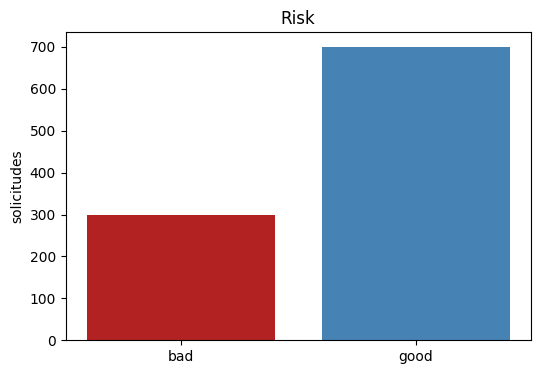

In [13]:
conteo = credit["Risk"].value_counts().loc[["bad", "good"]]
plt.bar(conteo.index.astype(str), conteo.values, color=["firebrick", "steelblue"])
plt.ylabel("solicitudes")
plt.title("Risk")
plt.show()


In [14]:
credit[['Age', 'Credit_amount', 'Duration']].describe().round(2)


,Age,Credit_amount,Duration
count,1000.00,1000.00,1000.00
mean,35.55,3271.26,20.90
std,11.38,2822.74,12.06
min,19.00,250.00,4.00
25%,27.00,1365.50,12.00
50%,33.00,2319.50,18.00
75%,42.00,3972.25,24.00
max,75.00,18424.00,72.00


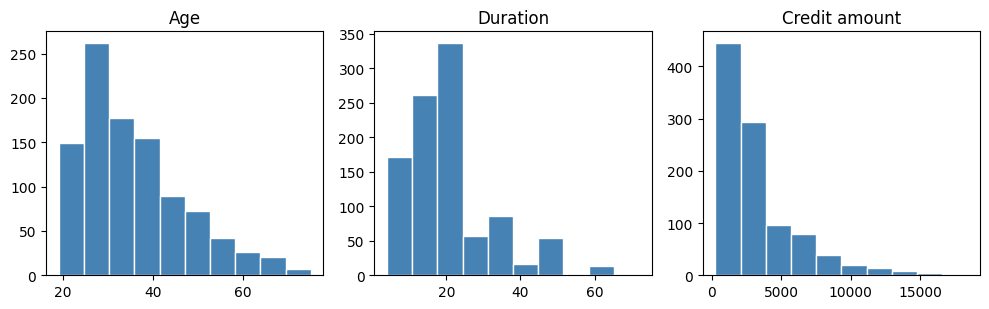

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
axes[0].hist(credit["Age"], color="steelblue", edgecolor="white")
axes[0].set_title("Age")
axes[1].hist(credit["Duration"], color="steelblue", edgecolor="white")
axes[1].set_title("Duration")
axes[2].hist(credit["Credit_amount"], color="steelblue", edgecolor="white")
axes[2].set_title("Credit amount")
plt.tight_layout()
plt.show()


Los vacíos de ahorro y corriente aparecen si pedimos `dropna=False`.


In [16]:
credit['Sex'].value_counts()


Sex
male      690
female    310
Name: count, dtype: int64

In [17]:
credit['Job'].value_counts().sort_index()


Job
0     22
1    200
2    630
3    148
Name: count, dtype: int64

In [18]:
credit['Housing'].value_counts()


Housing
own     713
rent    179
free    108
Name: count, dtype: int64

In [19]:
credit['Saving_accounts'].value_counts(dropna=False)


Saving_accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [20]:
credit['Checking_account'].value_counts(dropna=False)


Checking_account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

In [21]:
credit['Purpose'].value_counts()


Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

`Age`, `Duration` y `Credit_amount` según `Risk`:


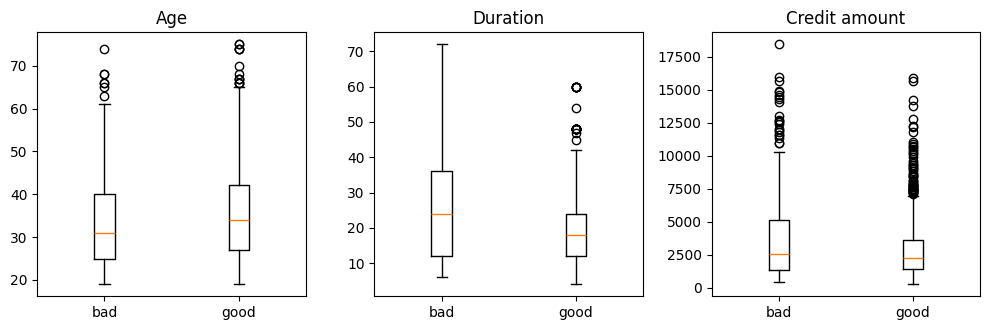

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, col, titulo in zip(
    axes,
    ["Age", "Duration", "Credit_amount"],
    ["Age", "Duration", "Credit amount"],
):
    grupos = [credit.loc[credit["Risk"] == r, col].dropna() for r in ["bad", "good"]]
    ax.boxplot(grupos)
    ax.set_xticklabels(["bad", "good"])
    ax.set_title(titulo)
plt.tight_layout()
plt.show()


In [23]:
credit.groupby('Risk', observed=True)[['Age', 'Duration', 'Credit_amount']].median()


,Age,Duration,Credit_amount
Risk,,,
bad,31.0,24.0,2574.5
good,34.0,18.0,2244.0


Tablas cruzadas y prueba ji-cuadrado de `Risk` contra algunos factores:


In [24]:
tab_sex = pd.crosstab(credit['Sex'], credit['Risk'])
print(tab_sex)
chi2, p, dof, exp = chi2_contingency(tab_sex)
print('p =', round(p, 4))


Risk    bad  good
Sex              
female  109   201
male    191   499
p = 0.0207


In [25]:
tab_saving = pd.crosstab(credit['Saving_accounts'], credit['Risk'], dropna=False)
print(tab_saving)
chi2, p, dof, exp = chi2_contingency(tab_saving.fillna(0).values)
print('p =', round(p, 4))


Risk             bad  good
Saving_accounts           
NaN               32   151
little           217   386
moderate          34    69
quite rich        11    52
rich               6    42
p = 0.0


In [26]:
tab_checking = pd.crosstab(credit['Checking_account'], credit['Risk'], dropna=False)
print(tab_checking)
chi2, p, dof, exp = chi2_contingency(tab_checking.fillna(0).values)
print('p =', round(p, 4))


Risk              bad  good
Checking_account           
NaN                46   348
little            135   139
moderate          105   164
rich               14    49
p = 0.0


In [27]:
tab_housing = pd.crosstab(credit['Housing'], credit['Risk'])
print(tab_housing)
chi2, p, dof, exp = chi2_contingency(tab_housing)
print('p =', round(p, 4))


Risk     bad  good
Housing           
free      44    64
own      186   527
rent      70   109
p = 0.0001


In [28]:
tab_purpose = pd.crosstab(credit['Purpose'], credit['Risk'])
print(tab_purpose)
chi2, p, dof, exp = chi2_contingency(tab_purpose)
print('p =', round(p, 4))

Risk                 bad  good
Purpose                       
business              34    63
car                  106   231
domestic appliances    4     8
education             23    36
furniture/equipment   58   123
radio/TV              62   218
repairs                8    14
vacation/others        5     7
p = 0.0579


Las tablas incluyen el `NA` de las cuentas cuando se pide `dropna=False`. Más adelante el modelo usa solo filas con ambas cuentas informadas.


# 4. OLS con $y$ 0/1

Misma $x$ continua (`Duration`) y respuesta 0/1, estimada con `smf.ols`:


In [29]:
credit['good'].head()


0    1
1    0
2    1
3    1
4    0
Name: good, dtype: int64

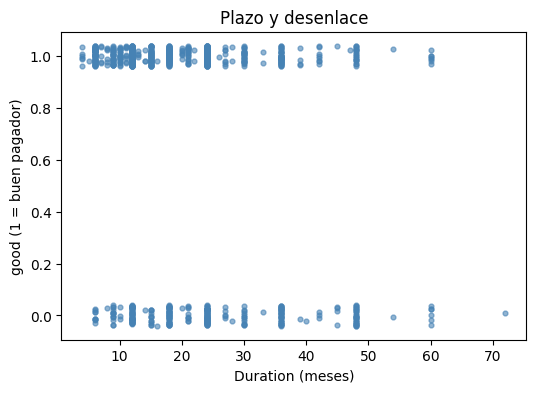

In [30]:
rng = np.random.default_rng(1)
y_jit = credit['good'] + rng.uniform(-0.04, 0.04, len(credit))
plt.scatter(credit['Duration'], y_jit, c='steelblue', s=12, alpha=0.6)
plt.xlabel('Duration (meses)')
plt.ylabel('good (1 = buen pagador)')
plt.title('Plazo y desenlace')
plt.show()


In [31]:
ols = smf.ols('good ~ Duration', data=credit).fit()
print(ols.params)


Intercept    0.870813
Duration    -0.008172
dtype: float64


In [32]:
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                   good   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     48.33
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           6.49e-12
Time:                        14:27:46   Log-Likelihood:                -614.97
No. Observations:                1000   AIC:                             1234.
Df Residuals:                     998   BIC:                             1244.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8708      0.028     30.704      0.0

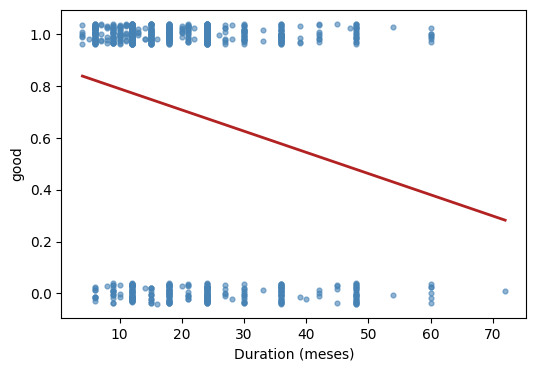

In [33]:
plt.scatter(credit['Duration'], y_jit, c='steelblue', s=12, alpha=0.6)
x_line = np.linspace(credit['Duration'].min(), credit['Duration'].max(), 50)
plt.plot(x_line, ols.params['Intercept'] + ols.params['Duration'] * x_line,
         color='firebrick', lw=2)
plt.xlabel('Duration (meses)')
plt.ylabel('good')
plt.show()


En este ajuste:

1. El valor ajustado de OLS no está restringido a $[0,1]$.
2. Los residuos se concentran en dos bandas (alrededor de 0 y de 1), porque $y$ es binaria.


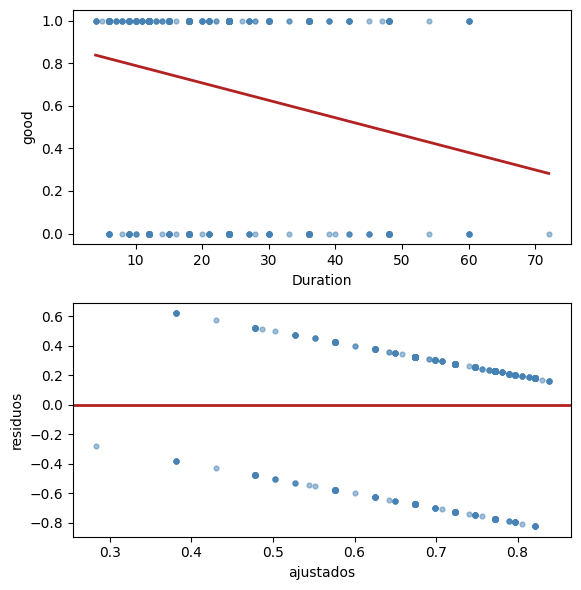

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))
axes[0].scatter(credit['Duration'], credit['good'], c='steelblue', s=12, alpha=0.5)
axes[0].plot(x_line, ols.params['Intercept'] + ols.params['Duration'] * x_line,
             color='firebrick', lw=2)
axes[0].set_xlabel('Duration')
axes[0].set_ylabel('good')
axes[1].scatter(ols.fittedvalues, ols.resid, c='steelblue', s=12, alpha=0.5)
axes[1].axhline(0, color='firebrick', lw=2)
axes[1].set_xlabel('ajustados')
axes[1].set_ylabel('residuos')
plt.tight_layout()
plt.show()


# 5. El logit simple

Misma $x$, estimado con `smf.logit` (liga logit).


In [35]:
fit = smf.logit('good ~ Duration', data=credit).fit(disp=False)
print(fit.params)


Intercept    1.666351
Duration    -0.037538
dtype: float64


In [36]:
print(fit.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      998
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.03652
Time:                        14:27:46   Log-Likelihood:                -588.56
converged:                       True   LL-Null:                       -610.86
Covariance Type:            nonrobust   LLR p-value:                 2.399e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6664      0.147     11.365      0.000       1.379       1.954
Duration      -0.0375      0.006     -6.582      0.000      -0.049      -0.026


In [37]:
fit.params


Intercept    1.666351
Duration    -0.037538
dtype: float64

In [38]:
np.exp(fit.params)


Intercept    5.292821
Duration     0.963158
dtype: float64

Los coeficientes están en **log-odds**. `np.exp(params)` los pasa a odds ratios: $>1$ sube las odds de `good`; $<1$ las baja.

De log-odds a probabilidad en un plazo dado (18 meses):


In [39]:
b0 = fit.params['Intercept']
b1 = fit.params['Duration']
eta = b0 + b1 * 18
odds = np.exp(eta)
p = odds / (1 + odds)
pd.Series({'log_odds': eta, 'odds': odds, 'P_good': p})


log_odds    0.990673
odds        2.693046
P_good      0.729221
dtype: float64

La curva en S: `predict` devuelve $P(\texttt{good})$.


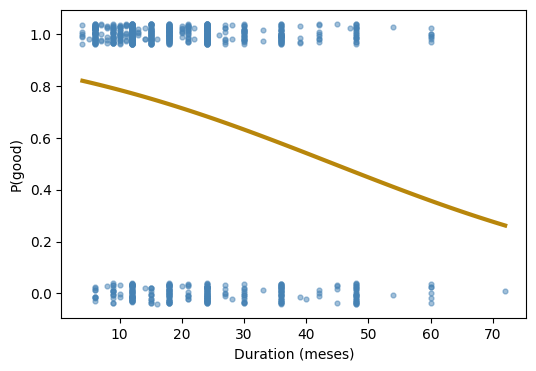

In [40]:
grid = pd.DataFrame({
    'Duration': np.linspace(credit['Duration'].min(), credit['Duration'].max(), 80)
})
grid['p'] = fit.predict(grid)

plt.scatter(credit['Duration'], y_jit, c='steelblue', s=12, alpha=0.5)
plt.plot(grid['Duration'], grid['p'], color='darkgoldenrod', lw=3)
plt.xlabel('Duration (meses)')
plt.ylabel('P(good)')
plt.show()


# 6. Filas completas y partición

`Saving_accounts` y `Checking_account` tienen `NA`. El logit de las secciones siguientes se estima sobre las filas con ambas cuentas informadas.


In [41]:
credit.isna().sum()


Age                   0
Sex                   0
Job                   0
Housing               0
Saving_accounts     183
Checking_account    394
Credit_amount         0
Duration              0
Purpose               0
Risk                  0
good                  0
dtype: int64

In [42]:
credit_completo = credit.dropna(subset=['Saving_accounts', 'Checking_account']).copy()
credit_completo['Saving_accounts'] = credit_completo['Saving_accounts'].astype('category')
credit_completo['Checking_account'] = credit_completo['Checking_account'].astype('category')
credit_completo.shape


(522, 11)

In [43]:
credit_completo['Risk'].value_counts()


Risk
good    291
bad     231
Name: count, dtype: int64

In [44]:
credit_completo['Risk'].value_counts(normalize=True)


Risk
good    0.557471
bad     0.442529
Name: proportion, dtype: float64

Quedan 522 filas. La proporción de `good` en este recorte se imprime arriba.

Partición 70 / 30 con `numpy` (`default_rng(8)`). No es el mismo sorteo que `set.seed(42)` en R.


In [45]:
credit_completo.shape[0]*0.3

156.6

In [46]:
np.random.seed(42)
rng = np.random.default_rng(8)
n = len(credit_completo)
n_train = int(round(0.7 * n))
train_pos = rng.choice(n, size=n_train, replace=False)
mask = np.zeros(n, dtype=bool)
mask[train_pos] = True
Train_Data = credit_completo.iloc[mask].copy()
Test_Data = credit_completo.iloc[~mask].copy()


In [47]:
Train_Data.shape


(365, 11)

In [48]:
Test_Data.shape


(157, 11)

In [49]:
Train_Data.head(10)


,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose,Risk,good
4,53,male,2,free,little,little,4870,24,car,bad,0
7,35,male,3,rent,little,moderate,6948,36,car,good,1
9,28,male,3,own,little,moderate,5234,30,car,bad,0
10,25,female,2,rent,little,moderate,1295,12,car,bad,0
11,24,female,2,rent,little,little,4308,48,business,bad,0
13,60,male,1,own,little,little,1199,24,car,bad,0
18,44,female,3,free,little,moderate,12579,24,car,bad,0
21,44,male,2,rent,quite rich,little,2647,6,radio/TV,good,1
25,36,male,1,own,little,little,1374,6,furniture/equipment,good,1
27,42,female,2,rent,rich,rich,409,12,radio/TV,good,1


In [50]:
Train_Data['Risk'].value_counts()


Risk
good    201
bad     164
Name: count, dtype: int64

In [51]:
Test_Data['Risk'].value_counts()


Risk
good    90
bad     67
Name: count, dtype: int64

# 7. Varios logits

Se estima, se imprime el `summary()` y se anota el AIC. Las categorías entran con `C(...)`.


## Solo el plazo


In [52]:
fit1 = smf.logit('good ~ Duration', data=Train_Data).fit(disp=False)
print(fit1.params)


Intercept    1.201749
Duration    -0.048625
dtype: float64


In [53]:
print(fit1.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      363
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.05477
Time:                        14:27:47   Log-Likelihood:                -237.37
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 1.563e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2017      0.226      5.308      0.000       0.758       1.645
Duration      -0.0486      0.010     -4.979      0.000      -0.068      -0.029


In [54]:
fit1.aic


np.float64(478.73088684792253)

In [55]:
#odds-ratios
np.exp(fit1.params)

Intercept    3.325928
Duration     0.952538
dtype: float64

## Plazo y edad


In [56]:
fit2 = smf.logit('good ~ Age + Duration', data=Train_Data).fit(disp=False)
print(fit2.params)


Intercept    0.958258
Age          0.006951
Duration    -0.048763
dtype: float64


In [57]:
print(fit2.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      362
Method:                           MLE   Df Model:                            2
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.05591
Time:                        14:27:47   Log-Likelihood:                -237.08
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 7.987e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9583      0.392      2.442      0.015       0.189       1.727
Age            0.0070      0.009      0.753      0.452      -0.011       0.025
Duration      -0.0488      0.010     -4.993      0.0

In [58]:
fit2.aic


np.float64(480.1598456751474)

In [59]:
np.exp(fit2.params)

Intercept    2.607152
Age          1.006975
Duration     0.952407
dtype: float64

## Sumamos el sexo


In [60]:
fit3 = smf.logit('good ~ Age + Duration + C(Sex)', data=Train_Data).fit(disp=False)
print(fit3.params)


Intercept         0.768295
C(Sex)[T.male]    0.433544
Age               0.004999
Duration         -0.050446
dtype: float64


In [61]:
print(fit3.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      361
Method:                           MLE   Df Model:                            3
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.06257
Time:                        14:27:47   Log-Likelihood:                -235.41
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 6.911e-07
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.7683      0.407      1.888      0.059      -0.029       1.566
C(Sex)[T.male]     0.4335      0.237      1.826      0.068      -0.032       0.899
Age                0.0050      0.009

In [62]:
np.exp(fit3.params)

Intercept         2.156088
C(Sex)[T.male]    1.542716
Age               1.005012
Duration          0.950805
dtype: float64

## Sumamos el ahorro


In [63]:
fit4 = smf.logit(
    'good ~ Age + Duration + C(Sex) + C(Saving_accounts)',
    data=Train_Data,
).fit(disp=False)
print(fit4.params)


Intercept                           0.644539
C(Sex)[T.male]                      0.424974
C(Saving_accounts)[T.moderate]      0.487412
C(Saving_accounts)[T.quite rich]    0.584463
C(Saving_accounts)[T.rich]          0.822259
Age                                 0.005519
Duration                           -0.050475
dtype: float64


In [64]:
print(fit4.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      358
Method:                           MLE   Df Model:                            6
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.07138
Time:                        14:27:47   Log-Likelihood:                -233.20
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 2.951e-06
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.6445      0.414      1.557      0.119      -0.167       1.456
C(Sex)[T.male]                       0.4250      0.239      1.776

## Sumamos la cuenta corriente

El factor tiene tres niveles (`little`, `moderate`, `rich`). Patsy deja uno de referencia (el primero, en el orden de las categorías) y estima los otros dos.


In [65]:
fit5 = smf.logit(
    'good ~ Age + Duration + C(Sex) + C(Saving_accounts) + C(Checking_account)',
    data=Train_Data,
).fit(disp=False)
print(fit5.params)


Intercept                           0.368552
C(Sex)[T.male]                      0.487976
C(Saving_accounts)[T.moderate]      0.354042
C(Saving_accounts)[T.quite rich]    0.480219
C(Saving_accounts)[T.rich]          0.688295
C(Checking_account)[T.moderate]     0.311614
C(Checking_account)[T.rich]         1.362638
Age                                 0.004615
Duration                           -0.048496
dtype: float64


In [66]:
print(fit5.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      356
Method:                           MLE   Df Model:                            8
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.09160
Time:                        14:27:47   Log-Likelihood:                -228.12
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 2.374e-07
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.3686      0.440      0.838      0.402      -0.493       1.230
C(Sex)[T.male]                       0.4880      0.245      1.992

In [67]:
fit5.aic


np.float64(474.2375474714669)

Mismo modelo más `Housing`, `Job` y `Credit_amount`. AIC de `fit1` a `fit6`:


In [68]:
fit6 = smf.logit(
    'good ~ Age + Duration + C(Sex) + C(Saving_accounts) + C(Checking_account) + C(Housing) + C(Job) + Credit_amount',
    data=Train_Data,
).fit(disp=False)
print(fit6.params)


Intercept                          -6.192584e-01
C(Sex)[T.male]                      4.624749e-01
C(Saving_accounts)[T.moderate]      4.100776e-01
C(Saving_accounts)[T.quite rich]    5.220090e-01
C(Saving_accounts)[T.rich]          6.743666e-01
C(Checking_account)[T.moderate]     2.819630e-01
C(Checking_account)[T.rich]         1.391628e+00
C(Housing)[T.own]                   6.915421e-01
C(Housing)[T.rent]                  5.458200e-01
C(Job)[T.1]                         2.983577e-01
C(Job)[T.2]                         1.543475e-01
C(Job)[T.3]                         1.285935e-01
Age                                 9.074190e-03
Duration                           -4.370894e-02
Credit_amount                      -1.172818e-07
dtype: float64


In [69]:
print(fit6.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      350
Method:                           MLE   Df Model:                           14
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.1000
Time:                        14:27:47   Log-Likelihood:                -226.00
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 5.551e-06
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -0.6193      0.937     -0.661      0.509      -2.455       1.217
C(Sex)[T.male]                       0.4625      0.255      1.811

In [70]:
pd.Series({
    'fit1': fit1.aic,
    'fit2': fit2.aic,
    'fit3': fit3.aic,
    'fit4': fit4.aic,
    'fit5': fit5.aic,
    'fit6': fit6.aic,
})


fit1    478.730887
fit2    480.159846
fit3    478.813312
fit4    480.392823
fit5    474.237547
fit6    481.993321
dtype: float64

# 8. Modelo para predicción

A partir de aquí se usa **fit5** (Age, Duration, Sex, Saving_accounts, Checking_account) para `predict` en test. El objeto se llama `logit_fits`.


In [71]:
logit_fits = smf.logit(
    'good ~ Age + Duration + C(Sex) + C(Saving_accounts) + C(Checking_account)',
    data=Train_Data,
).fit(disp=False)
print(logit_fits.params)


Intercept                           0.368552
C(Sex)[T.male]                      0.487976
C(Saving_accounts)[T.moderate]      0.354042
C(Saving_accounts)[T.quite rich]    0.480219
C(Saving_accounts)[T.rich]          0.688295
C(Checking_account)[T.moderate]     0.311614
C(Checking_account)[T.rich]         1.362638
Age                                 0.004615
Duration                           -0.048496
dtype: float64


In [72]:
print(logit_fits.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      356
Method:                           MLE   Df Model:                            8
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.09160
Time:                        14:27:47   Log-Likelihood:                -228.12
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 2.374e-07
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.3686      0.440      0.838      0.402      -0.493       1.230
C(Sex)[T.male]                       0.4880      0.245      1.992

In [73]:
logit_fits.summary().tables[1]


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,0.3686,0.440,0.838,0.402,-0.493,1.230
C(Sex)[T.male],0.4880,0.245,1.992,0.046,0.008,0.968
C(Saving_accounts)[T.moderate],0.3540,0.367,0.965,0.335,-0.365,1.073
C(Saving_accounts)[T.quite rich],0.4802,0.584,0.822,0.411,-0.664,1.625
C(Saving_accounts)[T.rich],0.6883,0.633,1.088,0.277,-0.552,1.928
C(Checking_account)[T.moderate],0.3116,0.239,1.302,0.193,-0.158,0.781
C(Checking_account)[T.rich],1.3626,0.465,2.933,0.003,0.452,2.273
Age,0.0046,0.010,0.481,0.630,-0.014,0.023
Duration,-0.0485,0.010,-4.785,0.000,-0.068,-0.029


In [74]:
logit_fits.pvalues


Intercept                           0.401919
C(Sex)[T.male]                      0.046322
C(Saving_accounts)[T.moderate]      0.334687
C(Saving_accounts)[T.quite rich]    0.410910
C(Saving_accounts)[T.rich]          0.276669
C(Checking_account)[T.moderate]     0.193056
C(Checking_account)[T.rich]         0.003358
Age                                 0.630463
Duration                            0.000002
dtype: float64

In [75]:
logit_fits.params


Intercept                           0.368552
C(Sex)[T.male]                      0.487976
C(Saving_accounts)[T.moderate]      0.354042
C(Saving_accounts)[T.quite rich]    0.480219
C(Saving_accounts)[T.rich]          0.688295
C(Checking_account)[T.moderate]     0.311614
C(Checking_account)[T.rich]         1.362638
Age                                 0.004615
Duration                           -0.048496
dtype: float64

In [76]:
np.exp(logit_fits.params)


Intercept                           1.445640
C(Sex)[T.male]                      1.629016
C(Saving_accounts)[T.moderate]      1.424816
C(Saving_accounts)[T.quite rich]    1.616429
C(Saving_accounts)[T.rich]          1.990319
C(Checking_account)[T.moderate]     1.365627
C(Checking_account)[T.rich]         3.906487
Age                                 1.004626
Duration                            0.952661
dtype: float64

Odds ratio respecto de $P(\texttt{good})$:

- $> 1$: odds de `good` más altas que en la referencia.
- $< 1$: odds de `good` más bajas que en la referencia.

Cada dummy se lee contra el nivel de referencia del factor.


# 9. Predicción en test

`predict` entrega $P(\texttt{good})$. Después se corta en 0.5 y se obtiene una etiqueta `good` / `bad`.


In [77]:
logit_probs = logit_fits.predict(Test_Data)
logit_probs.head(10)


1     0.175648
3     0.274356
12    0.549770
14    0.442834
15    0.427115
22    0.644074
23    0.758284
30    0.759447
34    0.786093
35    0.289295
dtype: float64

In [78]:
logit_pred = np.where(logit_probs > 0.5, 'good', 'bad')
logit_pred[:10]


array(['bad', 'bad', 'good', 'bad', 'bad', 'good', 'good', 'good', 'good',
       'bad'], dtype='<U4')

In [79]:
actuals_preds = pd.DataFrame({
    'actuals': Test_Data['Risk'].astype(str).to_numpy(),
    'predicteds': logit_pred,
    'probs': logit_probs.to_numpy(),
})
actuals_preds.head()


,actuals,predicteds,probs
0,bad,bad,0.175648
1,good,bad,0.274356
2,good,good,0.549770
3,good,bad,0.442834
4,bad,bad,0.427115


In [80]:
conf = pd.crosstab(logit_pred, Test_Data['Risk'], rownames=['Predicho'], colnames=['Real'])
conf


Real,bad,good
Predicho,,
bad,41,32
good,26,58


In [81]:
pd.crosstab(
    logit_pred, Test_Data['Risk'],
    rownames=['Predicho'], colnames=['Real'],
    margins=True,
)


Real,bad,good,All
Predicho,,,
bad,41,32,73
good,26,58,84
All,67,90,157


In [82]:
(logit_pred == Test_Data['Risk'].astype(str).to_numpy()).mean()


np.float64(0.6305732484076433)

Accuracy = aciertos / $n$ de test.

En la tabla, columnas = observado, filas = predicho:

- predijo `good` y era `bad`;
- predijo `bad` y era `good`.

La celda siguiente usa también el umbral 0.6.


In [83]:
print((logit_pred == Test_Data['Risk'].astype(str).to_numpy()).mean())

logit_pred_estricto = np.where(logit_probs > 0.6, 'good', 'bad')
print(pd.crosstab(logit_pred_estricto, Test_Data['Risk'], rownames=['Predicho'], colnames=['Real']))
print((logit_pred_estricto == Test_Data['Risk'].astype(str).to_numpy()).mean())


0.6305732484076433
Real      bad  good
Predicho           
bad        53    45
good       14    45
0.6242038216560509


# 10. Un par de perfiles

`predict` sobre un `DataFrame` con las mismas columnas que la fórmula.


In [84]:
nueva = pd.DataFrame({
    'Age': [35],
    'Duration': [18],
    'Sex': pd.Categorical(['male'], categories=Train_Data['Sex'].cat.categories),
    'Saving_accounts': pd.Categorical(['little'], categories=Train_Data['Saving_accounts'].cat.categories),
    'Checking_account': pd.Categorical(['little'], categories=Train_Data['Checking_account'].cat.categories),
})
nueva


,Age,Duration,Sex,Saving_accounts,Checking_account
0,35,18,male,little,little


In [85]:
logit_fits.predict(nueva)


0    0.536218
dtype: float64

In [86]:
perfiles = pd.DataFrame({
    'Age': [35, 35, 50, 24],
    'Duration': [18, 18, 12, 48],
    'Sex': pd.Categorical(['male', 'female', 'male', 'female'],
                          categories=Train_Data['Sex'].cat.categories),
    'Saving_accounts': pd.Categorical(['little', 'little', 'rich', 'little'],
                                      categories=Train_Data['Saving_accounts'].cat.categories),
    'Checking_account': pd.Categorical(['little', 'little', 'rich', 'little'],
                                       categories=Train_Data['Checking_account'].cat.categories),
})
perfiles['P_good'] = logit_fits.predict(perfiles)
perfiles


,Age,Duration,Sex,Saving_accounts,Checking_account,P_good
0,35,18,male,little,little,0.536218
1,35,18,female,little,little,0.415117
2,50,12,male,rich,rich,0.927993
3,24,48,female,little,little,0.136049


# Cierre

- OLS: `smf.ols`. Logit: `smf.logit`. La $y$ del logit es 0/1.
- Fórmula: `y ~ x1 + x2 + C(factor)`.
- `summary()`, AIC, `np.exp(params)`.
- En test: `predict` → umbral → `crosstab` → proporción de aciertos.

**Paquetes.** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scipy`. En Colab: runtime de Python y el CSV en el entorno.
